In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


In [5]:

rolls = np.random.randint(1, 7, size=100_000)

p_even = (rolls % 2 == 0).mean()
p_gt4  = (rolls > 4).mean()
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

P(even) ~ 0.498  (true 0.5)
P(>4)   ~ 0.332  (true 0.333)


In [4]:

p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [3]:
#lab exercise
coins = np.random.randint(0, 2, size=(100_000, 2))
heads = coins.sum(axis=1)
p_both_heads = (heads == 2).mean()
p_at_least_one = (heads >= 1).mean()
p_0_heads = (heads == 0).mean()
p_1_head = (heads == 1).mean()
p_2_heads = (heads == 2).mean()

total = p_0_heads + p_1_head + p_2_heads

print("P(both heads)       ~", round(p_both_heads, 3), "(true 0.25)")
print("P(at least one head)~", round(p_at_least_one, 3), "(true 0.75)")

print("\nP(0 heads) =", round(p_0_heads, 3))
print("P(1 head)  =", round(p_1_head, 3))
print("P(2 heads) =", round(p_2_heads, 3))

print("\nTotal =", round(total, 3), "-> should be close to 1")


P(both heads)       ~ 0.252 (true 0.25)
P(at least one head)~ 0.749 (true 0.75)

P(0 heads) = 0.251
P(1 head)  = 0.497
P(2 heads) = 0.252

Total = 1.0 -> should be close to 1


In [ ]:

rolls = np.random.randint(1, 7, size=100_000)
even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

In [ ]:

A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

In [6]:
#Lab Exercise
rolls = np.random.randint(1, 7, size=100_000)
less_than_4 = rolls[rolls < 4]
p_odd_given_less4 = (less_than_4 % 2 == 1).mean()
p_less4 = (rolls < 4).mean()
p_odd = (rolls % 2 == 1).mean()

print('P(odd | <4) ~', round(p_odd_given_less4, 3), '(true 2/3)')
print('P(<4)      ~', round(p_less4, 3), '(true 0.5)')
print('P(odd)     ~', round(p_odd, 3), '(true 0.5)')
print('Independent?', np.isclose(p_odd_given_less4, p_odd, atol=0.02))


P(odd | <4) ~ 0.668 (true 2/3)
P(<4)      ~ 0.499 (true 0.5)
P(odd)     ~ 0.503 (true 0.5)
Independent? False


In [7]:


p_disease   = 0.01
p_pos_given_D  = 0.99
p_pos_given_nD = 0.01
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [ ]:

N = 1_000_000
has_disease = np.random.rand(N) < p_disease

tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,
                     np.random.rand(N) < p_pos_given_nD)

among_positive = has_disease[tests_pos]
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

In [8]:

# LAB EXERCISE 3
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_not_spam = 0.05

# 2. Total probability: P("free")
p_free = (
    p_free_given_spam * p_spam
    + p_free_given_not_spam * (1 - p_spam)
)

# 3. Bayes: P(spam | "free")
p_spam_given_free = (
    p_free_given_spam * p_spam
) / p_free

print('P("free") =', round(p_free, 3))
print('P(spam | "free") =', round(p_spam_given_free, 3))


P("free") = 0.16
P(spam | "free") = 0.75


In [9]:


bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')

pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')

Bernoulli(0.3) mean ~ 0.305 (true 0.3)
Poisson(4) mean ~ 3.983 (true 4)


In [ ]:

x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

Poisson(2) sample mean ~ 1.997
(true mean = 2)


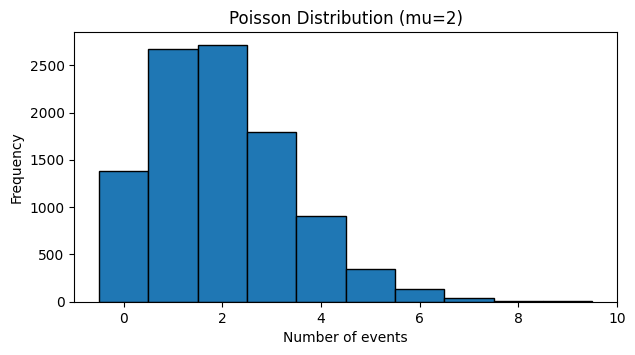

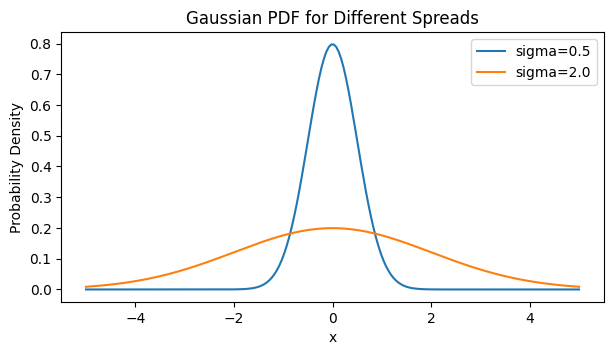

In [10]:

#LAB EXERCISE 4 — Simulate & plot distributions

# 1. POISSON DISTRIBUTION

pois = stats.poisson(mu=2).rvs(size=10_000)

# Print the sample mean
print('Poisson(2) sample mean ~', round(pois.mean(), 3))
print('(true mean = 2)')
# 2. HISTOGRAM OF POISSON SAMPLES

fig, ax = plt.subplots(figsize=(7, 3.5))

ax.hist(
    pois,
    bins=np.arange(pois.max() + 2) - 0.5,
    edgecolor='black'
)

ax.set_title('Poisson Distribution (mu=2)')
ax.set_xlabel('Number of events')
ax.set_ylabel('Frequency')

plt.show()

# 3. GAUSSIAN PDF WITH TWO DIFFERENT SIGMAS


x = np.linspace(-5, 5, 200)

fig, ax = plt.subplots(figsize=(7, 3.5))

# Two different standard deviations
for sigma in [0.5, 2.0]:
    ax.plot(
        x,
        stats.norm(0, sigma).pdf(x),
        label=f'sigma={sigma}'
    )

ax.set_title('Gaussian PDF for Different Spreads')
ax.set_xlabel('x')
ax.set_ylabel('Probability Density')

ax.legend()

plt.show()


In [11]:

from scipy.stats import entropy

fair   = [0.5, 0.5]
biased = [0.9, 0.1]
certain= [1.0, 0.0]
# base=2 gives entropy in BITS
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [12]:

# 🔹 5B. KL DIVERGENCE — how far is Q from P?
P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')

D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [ ]:


from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

In [14]:

die4 = [1/4] * 4
die6 = [1/6] * 6
H4 = entropy(die4, base=2)
H6 = entropy(die6, base=2)
print("Entropy 4-sided die =", round(H4, 3), "bits")
print("Entropy 6-sided die =", round(H6, 3), "bits")
print("More uncertain =", "6-sided die")
P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])
kl = entropy(P, Q, base=2)
print("D(P || Q) =", round(kl, 3), "bits")
print("Most informative: petal width (cm)")
print("Least informative: sepal width (cm)")


Entropy 4-sided die = 2.0 bits
Entropy 6-sided die = 2.585 bits
More uncertain = 6-sided die
D(P || Q) = 0.119 bits
Most informative: petal width (cm)
Least informative: sepal width (cm)
